In [14]:
# Run this cell first - installs all required libraries
# (Already available on Google Colab, but run anyway to be safe)
!pip install -q scikit-learn tensorflow torch torchvision
print("All libraries ready!")


All libraries ready!


# Perceptron - From Scratch to Libraries

A perceptron is the **simplest neural network** - just one node.

---

### How it works

```
         x1 ──(w1)──┐
                    ├──[ Σ + bias ]──[ step fn ]──→  0 or 1
         x2 ──(w2)──┘
```

| Step | What happens |
|---|---|
| **Input** | x1, x2 are the features (e.g. 0 or 1) |
| **Weights** | w1, w2 control how much each input matters |
| **Sum** | `x1×w1 + x2×w2 + bias` |
| **Step function** | if sum >= 0 → predict **1**, else → predict **0** |

**Key idea:** It learns by making mistakes. Every wrong prediction nudges the weights. Repeat enough times → weights become correct.


# Perceptron - From Scratch

## Step 1: Import Libraries and Create the Dataset


In [15]:
import numpy as np
import matplotlib.pyplot as plt

# ── Dataset: OR gate ──────────────────────────────────────────
# Each row is one sample (data point)
# Each column is one feature (input)
#
#   x1  x2  →  label
#    0   0  →    0    (0 OR 0 = 0)
#    0   1  →    1    (0 OR 1 = 1)
#    1   0  →    1    (1 OR 0 = 1)
#    1   1  →    1    (1 OR 1 = 1)

X_or = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])

y_or = np.array([0, 1, 1, 1])

print("X shape:", X_or.shape)   # (4 samples, 2 features)
print("y shape:", y_or.shape)   # (4 labels)

X shape: (4, 2)
y shape: (4,)


## Step 2: Define the Perceptron Class


In [16]:
class Perceptron:
    def __init__(self, learning_rate=0.1, epochs=20):
        self.lr = learning_rate       # how big each weight adjustment is
        self.epochs = epochs          # how many times to loop over the full dataset
        self.weights = None           # one weight per feature - learned during fit
        self.bias = None              # shifts the decision boundary
        self.errors_per_epoch = []    # track mistakes per epoch to see learning progress
        self.weights_history = []     # track weight values per epoch to see learning speed

    def predict(self, X):
        # Step 1: weighted sum of inputs  →  x1*w1 + x2*w2 + bias
        linear_output = np.dot(X, self.weights) + self.bias

        # Step 2: apply step function - output 1 if >= 0, else 0
        return np.where(linear_output >= 0, 1, 0)

    def fit(self, X, y):
        n_samples, n_features = X.shape

        # start weights and bias at zero - model knows nothing yet
        self.weights = np.zeros(n_features)
        self.bias = 0.0
        self.errors_per_epoch = []
        self.weights_history = []

        for _ in range(self.epochs):
            errors = 0

            # go through each sample one at a time
            for xi, target in zip(X, y):
                # predict for this single sample
                linear_output = np.dot(xi, self.weights) + self.bias
                y_pred = 1 if linear_output >= 0 else 0

                # update = how wrong were we × learning rate
                # if correct: target - y_pred = 0 → no update
                # if wrong:   target - y_pred = ±1 → nudge weights
                update = self.lr * (target - y_pred)

                # adjust each weight by update × the input that caused the error
                # (if xi=0 for that feature, it didn't contribute → weight unchanged)
                self.weights += update * xi
                self.bias    += update

                errors += int(update != 0)  # count this as a mistake if update != 0

            # record total mistakes this epoch
            self.errors_per_epoch.append(errors)

            # record a snapshot of weight[0] to show how fast weights are moving
            self.weights_history.append(self.weights[0])

## Step 3: Train the Perceptron on OR Data


In [17]:
p_or = Perceptron(learning_rate=0.1, epochs=20)  #make the box
p_or.fit(X_or, y_or) # fit that box with data



In [18]:
print("Learned weights:", p_or.weights)  # one weight per feature
print("Learned bias:   ", p_or.bias)



Learned weights: [0.1 0.1]
Learned bias:    -0.1


In [11]:
print("Predictions:    ", p_or.predict(X_or))
print("Expected:        [0 1 1 1]")

Predictions:     [0 1 1 1]
Expected:        [0 1 1 1]


## Step 4: Decision Boundary Plot


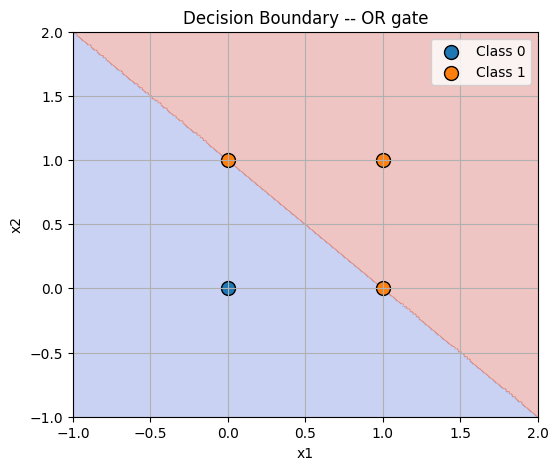

In [19]:
def plot_decision_boundary(X, y, model, title):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                         np.linspace(y_min, y_max, 300))
    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = model.predict(grid).reshape(xx.shape)

    plt.figure(figsize=(6, 5))
    plt.contourf(xx, yy, Z, alpha=0.3, cmap="coolwarm")
    for label in np.unique(y):
        pts = X[y == label]
        plt.scatter(pts[:, 0], pts[:, 1], s=100, edgecolor="black", label=f"Class {label}")
    plt.title(title)
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.legend()
    plt.grid(True)
    plt.show()

plot_decision_boundary(X_or, y_or, p_or, "Decision Boundary -- OR gate")


## Step 5: Plot Misclassifications per Epoch


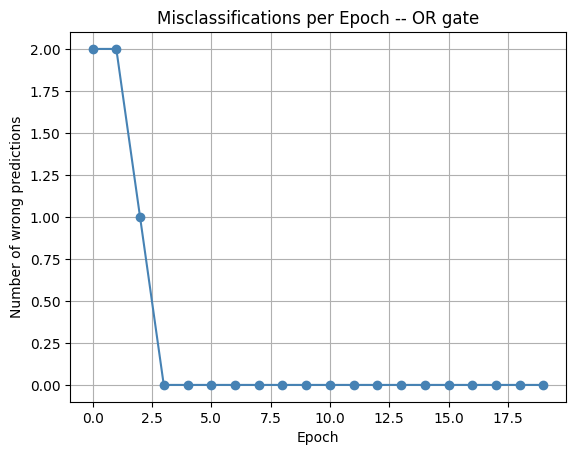

In [20]:
plt.plot(p_or.errors_per_epoch, marker="o", color="steelblue")
plt.title("Misclassifications per Epoch -- OR gate")
plt.xlabel("Epoch")
plt.ylabel("Number of wrong predictions")
plt.grid(True)
plt.show()


---
# Hands-on Tasks

Try these yourself. Run each one and observe what changes.

### Task 1 - AND gate
> Change OR to AND. Does the perceptron still learn?

```
AND truth table:
0 AND 0 = 0
0 AND 1 = 0
1 AND 0 = 0
1 AND 1 = 1   ← only true when BOTH inputs are 1
```

In [22]:
X_and = np.array([[0,0],[0,1],[1,0],[1,1]])
y_and = np.array([0, 0, 0, 1])   # only 1 when BOTH inputs are 1



In [23]:
#make the perceptron the empty box with learning rate and epoch
#name the variable p_and

#fit that with the data X_and and y_and  using p_and.fit



p_and = Perceptron(learning_rate=0.1, epochs=20)
p_and.fit(X_and, y_and)

In [24]:
print("Learned weights:", p_and.weights)  # one weight per feature
print("Learned bias:   ", p_and.bias)

Learned weights: [0.2 0.1]
Learned bias:    -0.20000000000000004


In [25]:


#predict the data using predict method and print that


print("Predictions:", p_and.predict(X_and))
print("Expected:    [0 0 0 1]")



Predictions: [0 0 0 1]
Expected:    [0 0 0 1]


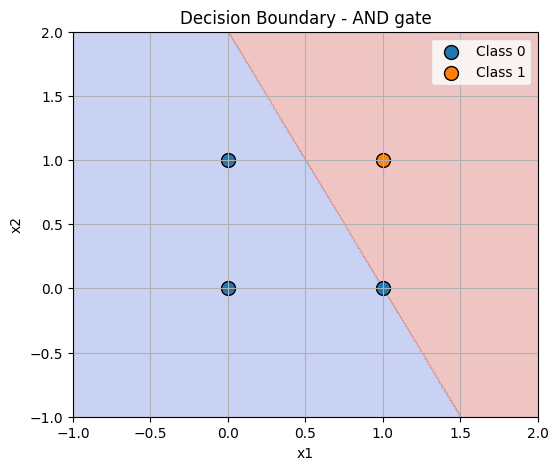

In [26]:
plot_decision_boundary(X_and, y_and, p_and, "Decision Boundary - AND gate")

---
## The XOR Problem

> **Task 2:** Try XOR. What happens?

```
XOR truth table:
0 XOR 0 = 0
0 XOR 1 = 1
1 XOR 0 = 1
1 XOR 1 = 0
```

Can you draw ONE straight line to separate 0s from 1s? Try on paper first.

In [28]:
X_xor = np.array([[0,0],[0,1],[1,0],[1,1]])
y_xor = np.array([0, 1, 1, 0])

print(f"X_xor=  {X_xor}")
print(f"y_xor=  {y_xor}")





X_xor=  [[0 0]
 [0 1]
 [1 0]
 [1 1]]
y_xor=  [0 1 1 0]


In [29]:
#make the perceptron the empty box with learning rate and epoch
#name the variable p_xor





#fit that with the data X_and and y_and  using p_and.fit





p_xor = Perceptron(learning_rate=0.1, epochs=20)
p_xor.fit(X_xor, y_xor)


In [31]:

#predict the data using predict method and print that





print("XOR Predictions:", p_xor.predict(X_xor))
print("Expected:        [0 1 1 0]")


XOR Predictions: [1 1 0 0]
Expected:        [0 1 1 0]


In [33]:
print("Errors per epoch:", p_xor.errors_per_epoch)
# notice: errors never reach 0 - the perceptron cannot learn XOR



Errors per epoch: [3, 3, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4]


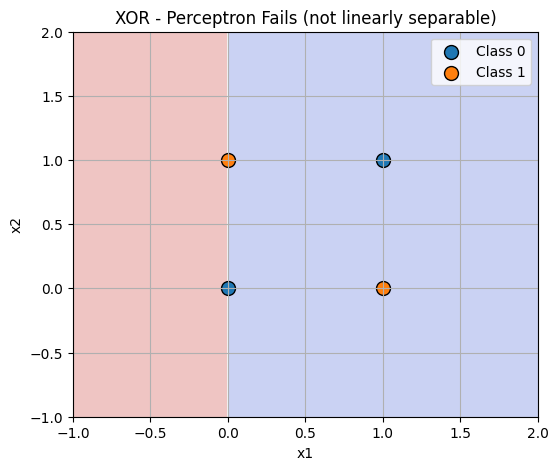

In [34]:
plot_decision_boundary(X_xor, y_xor, p_xor, "XOR - Perceptron Fails (not linearly separable)")


[tensorflow playground](https://playground.tensorflow.org/#activation=tanh&batchSize=10&dataset=circle&regDataset=reg-plane&learningRate=0.03&regularizationRate=0&noise=0&networkShape=4,2&seed=0.54884&showTestData=false&discretize=false&percTrainData=50&x=true&y=true&xTimesY=false&xSquared=false&ySquared=false&cosX=false&sinX=false&cosY=false&sinY=false&collectStats=false&problem=classification&initZero=false&hideText=false)

---
## Same Perceptron - 3 Libraries

The math is **identical** in all three. The library just handles the bookkeeping.

| | sklearn | TensorFlow | PyTorch |
|---|---|---|---|
| Style | `fit/predict` | `compile → fit` | manual loop |
| You control | least | medium | most |

> Understanding the from-scratch version means you understand all three.

### 1. scikit-learn Perceptron

In [35]:
from sklearn.linear_model import Perceptron as SklearnPerceptron

# sklearn wraps the same algorithm - max_iter=epochs, eta0=learning_rate
sk_model = SklearnPerceptron(max_iter=20, eta0=0.1, random_state=42)
sk_model.fit(X_or, y_or)



Perceptron(eta0=0.1, max_iter=20, random_state=42)

In [36]:
print("sklearn Perceptron")
print("Weights:", sk_model.coef_)        # same as our self.weights
print("Bias:   ", sk_model.intercept_)   # same as our self.bias
print("Predictions:", sk_model.predict(X_or))
print("Expected:    [0 1 1 1]")

sklearn Perceptron
Weights: [[0.2 0.2]]
Bias:    [-0.1]
Predictions: [0 1 1 1]
Expected:    [0 1 1 1]


### 2. TensorFlow / Keras - Single Dense Node

A perceptron is just a Dense layer with **1 unit** and a step-like activation.  
We use `sigmoid` (smooth approximation of step) + `binary_crossentropy` loss.

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 1.0000 - loss: 0.3741
Epoch 2/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 208ms/step - accuracy: 0.7500 - loss: 0.3522
Epoch 3/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step - accuracy: 0.7500 - loss: 0.3365
Epoch 4/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step - accuracy: 0.7500 - loss: 0.3245
Epoch 5/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step - accuracy: 0.7500 - loss: 0.3134
Epoch 6/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - accuracy: 0.7500 - loss: 0.3021
Epoch 7/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - accuracy: 0.7500 - loss: 0.2905
Epoch 8/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 198ms/step - accuracy: 0.7500 - loss: 0.2789
Epoch 9/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step - accuracy: 0.7500 - loss: 0.2674
Epoch 10/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 235ms/step - accuracy: 1.0000 - loss: 0.2562
Epoch 11/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 215ms/step - accuracy: 1.0000 - loss: 0.2454
Epoch 12/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step - accuracy: 1.00

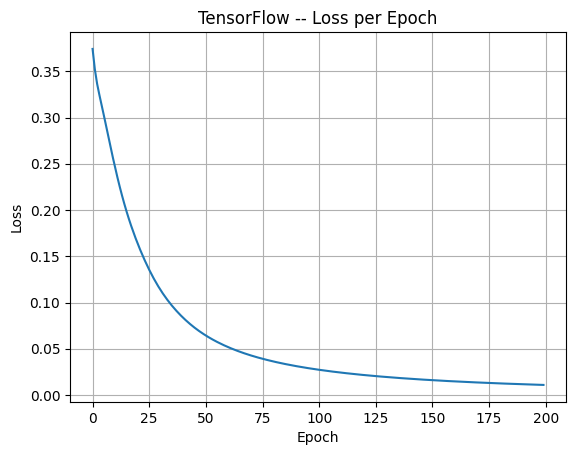

In [37]:
import tensorflow as tf
from tensorflow import keras

tf.random.set_seed(42)

# Step 1: create the empty model (the box)
tf_model = keras.Sequential()

# Step 2: add one Dense node with 1 unit - this IS the perceptron
# sigmoid is a smooth version of the step function (outputs 0 to 1)
tf_model.add(keras.layers.Dense(1, activation="sigmoid", input_shape=(2,)))

# Step 3: compile - tell the model how to measure error and how to update weights
# Adam: a smarter version of SGD that adapts the learning rate automatically
# binary_crossentropy: standard loss for 0/1 classification problems
tf_model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.1),
                 loss="binary_crossentropy",
                 metrics=["accuracy"])

# Step 4: train - same as fit() in our scratch version
history = tf_model.fit(X_or, y_or, epochs=200, verbose=1)

# Step 5: predict - anything >= 0.5 is class 1, else class 0
preds = (tf_model.predict(X_or, verbose=0) >= 0.5).astype(int).flatten()
print("TensorFlow Perceptron")
print("Weights:", tf_model.layers[0].get_weights()[0].flatten())
print("Bias:   ", tf_model.layers[0].get_weights()[1])
print("Predictions:", preds)
print("Expected:    [0 1 1 1]")

# plot how loss dropped over 200 epochs
plt.plot(history.history["loss"])
plt.title("TensorFlow -- Loss per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()


### 3. PyTorch - Single Linear Layer

In PyTorch there is no built-in `Perceptron` - you build it manually with `nn.Linear`.  
This is the closest to what we wrote from scratch, but PyTorch handles gradients via autograd.

Epoch  20/200 - loss: 0.2302
Epoch  40/200 - loss: 0.1250
Epoch  60/200 - loss: 0.0779
Epoch  80/200 - loss: 0.0543
Epoch 100/200 - loss: 0.0407
Epoch 120/200 - loss: 0.0319
Epoch 140/200 - loss: 0.0259
Epoch 160/200 - loss: 0.0216
Epoch 180/200 - loss: 0.0183
Epoch 200/200 - loss: 0.0158
PyTorch Perceptron
Weights: [7.5915403 7.6158643]
Bias:    [-3.3403804]
Predictions: [0 1 1 1]
Expected:    [0 1 1 1]


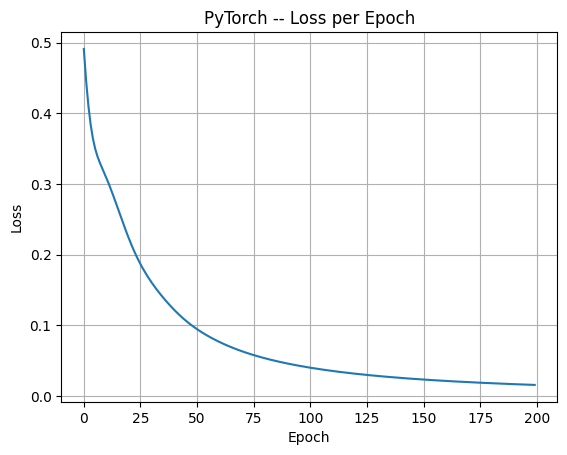

In [38]:
import torch
import torch.nn as nn

torch.manual_seed(42)

# PyTorch works with tensors, not numpy arrays - convert first
X_tensor = torch.tensor(X_or, dtype=torch.float32)
y_tensor = torch.tensor(y_or, dtype=torch.float32).unsqueeze(1)  # shape (4,1)

# Step 1: create the empty model (the box)
pt_model = nn.Sequential()

# Step 2: add layers
# nn.Linear(2,1) = weighted sum of 2 inputs → 1 output (same as np.dot + bias)
# nn.Sigmoid()   = smooth step function (same as TensorFlow sigmoid)
pt_model.add_module("linear",  nn.Linear(2, 1))
pt_model.add_module("sigmoid", nn.Sigmoid())

# Step 3: define loss and optimizer
# BCELoss = Binary Cross Entropy - same as binary_crossentropy in TF
# Adam    = same optimizer as TF, adapts learning rate automatically
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(pt_model.parameters(), lr=0.1)

# Step 4: training loop - PyTorch makes this explicit (TF hides it inside fit())
losses = []
for epoch in range(200):
    optimizer.zero_grad()              # clear gradients from last step
    output = pt_model(X_tensor)        # forward pass: predict
    loss = criterion(output, y_tensor) # compute loss
    loss.backward()                    # backward pass: compute gradients
    optimizer.step()                   # update weights using gradients
    losses.append(loss.item())

    if (epoch + 1) % 20 == 0:
            print(f"Epoch {epoch+1:3d}/200 - loss: {loss.item():.4f}")


# Step 5: predict
with torch.no_grad():  # no_grad = dont compute gradients during prediction
    preds = (pt_model(X_tensor) >= 0.5).int().flatten()

print("PyTorch Perceptron")
print("Weights:", pt_model.linear.weight.data.numpy().flatten())
print("Bias:   ", pt_model.linear.bias.data.numpy())
print("Predictions:", preds.numpy())
print("Expected:    [0 1 1 1]")

plt.plot(losses)
plt.title("PyTorch -- Loss per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()


---
## Perceptron as a Spam Filter

Forget logic gates. Let's solve a real problem.

Every email has features. We use just two:
- **feature 1** -- does it contain the word "free"? (1=yes, 0=no)
- **feature 2** -- does it contain the word "win"?  (1=yes, 0=no)

| Email | has "free" | has "win" | label |
|---|---|---|---|
| "Free tickets! You win!" | 1 | 1 | spam |
| "Free download available" | 1 | 0 | spam |
| "You could win a prize" | 0 | 1 | spam |
| "Meeting at 3pm" | 0 | 0 | not spam |

**Before running:** Can a single straight line separate spam from not-spam?

In [39]:
# features: [has "free", has "win"]
X_spam = np.array([
    [1, 1],   # "Free tickets! You win!"  -> spam
    [1, 0],   # "Free download"            -> spam
    [0, 1],   # "You could win a prize"    -> spam
    [0, 0],   # "Meeting at 3pm"           -> not spam
])
y_spam = np.array([1, 1, 1, 0])  # 1=spam, 0=not spam




In [ ]:
# make the perceptron box name the variable p_spam

p_spam = Perceptron(learning_rate=0.1, epochs=20)



# fit with data


p_spam.fit(X_spam, y_spam)


#predict using the same data




# see it is as expected or not



# and plot uisng this # plot_decision_boundary(X_spam, y_spam, p_spam, "Spam Filter -- Decision Boundary")


In [ ]:
print("Learned weights:", p_spam.weights)  # weight for "free" and "win"
print("Learned bias:   ", p_spam.bias)
print("Predictions:    ", p_spam.predict(X_spam))
print("Expected:        [1 1 1 0]")

In [ ]:
# p_spam = Perceptron(learning_rate=0.1, epochs=20)
# p_spam.fit(X_spam, y_spam)

# print("Learned weights:", p_spam.weights)  # weight for "free" and "win"
# print("Learned bias:   ", p_spam.bias)
# print("Predictions:    ", p_spam.predict(X_spam))
# print("Expected:        [1 1 1 0]")

# plot_decision_boundary(X_spam, y_spam, p_spam, "Spam Filter -- Decision Boundary")

In [ ]:
# YOUR TURN -- test the spam filter on new emails
new_emails = np.array([
    [1, 1],   # "Free! Win now!"
    [0, 0],   # "See you tomorrow"
    [1, 0],   # "Free pizza in the office"
    [0, 1],   # "Win a scholarship"
])
# code here















In [ ]:

# email_texts = [
#     "Free! Win now!",
#     "See you tomorrow",
#     "Free pizza in the office",
#     "Win a scholarship"
# ]

predictions = p_spam.predict(new_emails)
for text, pred in zip(email_texts, predictions):
    label = "SPAM    " if pred == 1 else "NOT SPAM"
    print(f"{label} <- {text}")
# predictions

NameError: name 'p_spam' is not defined

In [ ]:
# do this same thing using sklearn perceptron
# code here

---
## What's Next?

We saw that XOR **always fails**. The perceptron draws one straight line. XOR needs two.

**Question for the class:**
> *"What would you add to make it work?"*

The answer is **another layer** - which gives us a neural network.

```
Perceptron:        input → [node] → output
Neural Network:    input → [layer 1] → [layer 2] → output
```

Next session: Multi-Layer Perceptron (MLP) - solving XOR and beyond.